In [1]:
import tensorflow as tf

path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

text = open(path, 'rb').read().decode(encoding='utf-8')
print(text[:500])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [2]:
import numpy as np
vocab = sorted(set(text))          # unique characters
print(f'Total unique characters: {len(vocab)}')

# Character → Number
char2idx = {char: idx for idx, char in enumerate(vocab)}

# Number → Character
idx2char = np.array(vocab)

# Text → Number (Encoding)
text_as_int = np.array([char2idx[c] for c in text])

Total unique characters: 65


In [3]:
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]   #  100 characters = INPUT
    target_text = chunk[1:]   # 100 characters = ANSWER
    return input_text, target_text

dataset = sequences.map(split_input_target)
dataset = dataset.shuffle(10000).batch(64, drop_remainder=True)

In [4]:
vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 512

# ---- Simple RNN ----
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.SimpleRNN(rnn_units, return_sequences=False),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

# ---- LSTM ----
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.LSTM(rnn_units, return_sequences=False),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

# ---- GRU ----
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.GRU(rnn_units, return_sequences=False),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

In [5]:
# ---- Simple RNN ----
rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.SimpleRNN(rnn_units, return_sequences=True),  # ← True
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

# ---- LSTM ----
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.LSTM(rnn_units, return_sequences=True),       # ← True
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

# ---- GRU ----
gru_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,), batch_size=64),
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.GRU(rnn_units, return_sequences=True),        # ← True
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

In [6]:
def compile_and_train(model, name):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(dataset, epochs=100)
    return history

rnn_history  = compile_and_train(rnn_model,  "RNN")
lstm_history = compile_and_train(lstm_model, "LSTM")
gru_history  = compile_and_train(gru_model,  "GRU")

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3084 - loss: 2.5498
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4126 - loss: 2.0243
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4589 - loss: 1.8433
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4894 - loss: 1.7293
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5088 - loss: 1.6520
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5241 - loss: 1.5953
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5351 - loss: 1.5518
Epoch 8/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5434 - loss: 1.5177
Epoch 9/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5497 - loss: 1.4910
Epoch 10/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5554 - loss: 1.4678
Epoch 11/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5603 - loss: 1.4475
Epoch 12/100
172/172 ━━━━━━━━

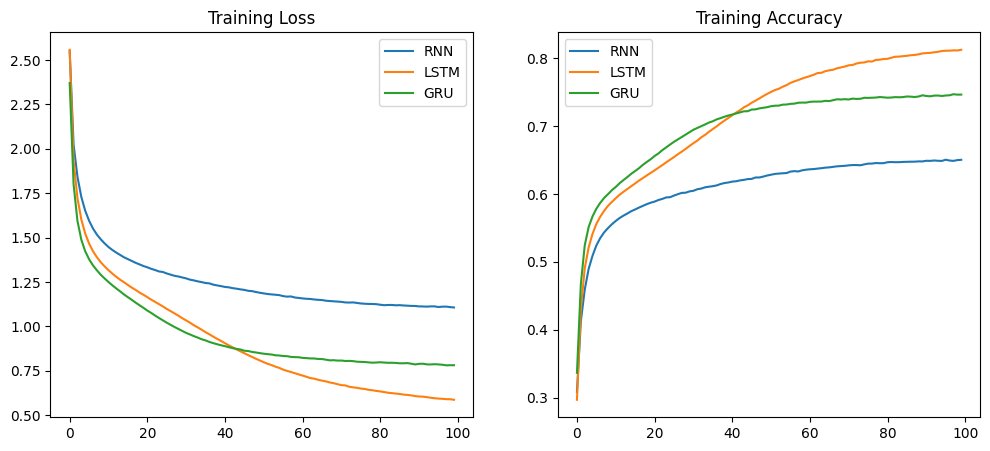

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['loss'],  label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'],  label='GRU')
plt.title('Training Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['accuracy'],  label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'],  label='GRU')
plt.title('Training Accuracy')
plt.legend()

plt.show()

In [8]:
def build_inference_model(trained_model, layer_type):
    inf_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(None,), batch_size=1),
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        layer_type(rnn_units, return_sequences=True),
        tf.keras.layers.Dense(vocab_size, activation='softmax')
    ])
    inf_model.set_weights(trained_model.get_weights())  # trained weights copy karo
    return inf_model

rnn_inf  = build_inference_model(rnn_model,  tf.keras.layers.SimpleRNN)
lstm_inf = build_inference_model(lstm_model, tf.keras.layers.LSTM)
gru_inf  = build_inference_model(gru_model,  tf.keras.layers.GRU)

In [9]:
def generate_text(model, start_string, num_generate=200):
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    generated = []
    # reset_states() hata diya

    for _ in range(num_generate):
        predictions = model(input_eval)
        predictions = predictions[:, -1, :]  # sirf last timestep lo

        predicted_id = tf.random.categorical(
            tf.math.log(predictions) / 0.2,
            num_samples=1
        )[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)
        generated.append(idx2char[predicted_id])

    return start_string + ''.join(generated)

print("RNN:\n",  generate_text(rnn_inf,  "ROMEO: "))
print("LSTM:\n", generate_text(lstm_inf, "ROMEO: "))
print("GRU:\n",  generate_text(gru_inf,  "ROMEO: "))

RNN:
 ROMEO: I t the t t the the the t s the t he the the the the sthe the the t me the courd the t the me he me the me the win the me he he the and the he the the t the he the win the t t the t t the the the t he
LSTM:
 ROMEO: PENGoure the th the the the hall the the thall the the thal the the the thare thar thathe the the than thoure the thal the t he s t the thalll this the this the the thoure the the thoure the the t the
GRU:
 ROMEO: juthe me the t the the t the the the the the he the the the he than t the the the the the the the the ind the the the the the we an the the the the the the an the the the he the t the the the the the 
